In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys
import pandas as pd

import cogwheel.cosmology
import cogwheel.data
import cogwheel.posterior
import cogwheel.sampling
import cogwheel.gw_plotting
import cogwheel.gw_utils
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

import gwosc
import gwpy.table
from pesummary.io import read

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
from parameter_estimation import load_posterior_samples, add_derived_quantities
from pe_injections import chirp_mass

In [3]:
# load injection results

# load our posterior samples and the released samples from the LVK PE
resdir = '../data/pe_runs_lensing/injections/IntrinsicLVCPrior'
# get the results here
event_dir_list = glob.glob(f'{resdir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 11 events


In [4]:
# plot parameters for our cogwheel results:
plot_params = [
    'm1',
    'm2',
    'iota',
    'p_lensed'
]

In [5]:
eventname_list

['GW17',
 'GW22',
 'GW124',
 'GW19',
 'GW123',
 'GW21',
 'GW100',
 'GW23',
 'GW24',
 'GW12',
 'GW20']

In [6]:
# load the event data
eventname = 'GW100'
i = eventname_list.index(eventname)
event_data = cogwheel.data.EventData.from_npz(filename=os.path.join(event_dir_list[i], 'run_0', f'{eventname}.npz'))

In [7]:
event_data.injection

{'par_dic': {'f_ref': 100.0,
  'm1': 60,
  'm2': 20,
  's1z': 0.0,
  's2z': 0.0,
  'psi': 0.5,
  'iota': 0.01,
  's1x_n': 0.0,
  's1y_n': 0.0,
  's2x_n': 0.0,
  's2y_n': 0.0,
  'ra': 3.0,
  'dec': -0.5,
  't_geocenter': 0.0,
  'phi_ref': 0.43867,
  'd_luminosity': 500.0,
  'l1': 0.0,
  'l2': 0.0},
 'approximant': 'IMRPhenomXPHM',
 'd_h': array([1621.7510599 , 2465.39316448,   38.63120897]),
 'h_h': array([1656.35661615, 2531.90665167,   45.19885838])}

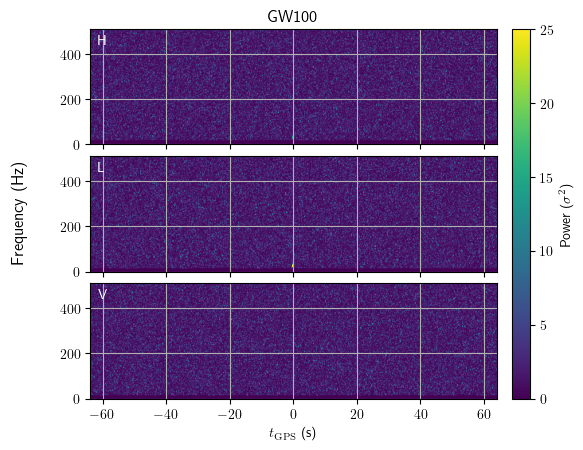

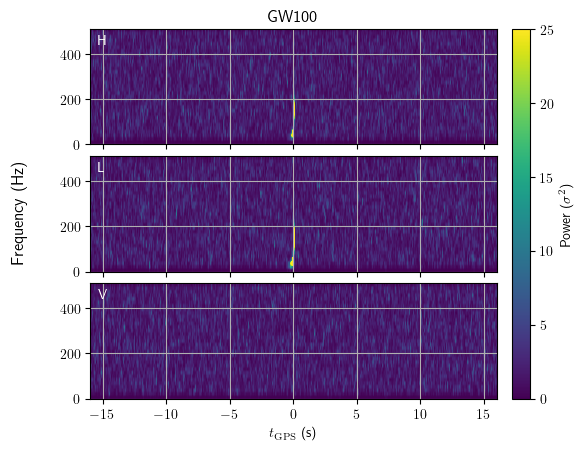

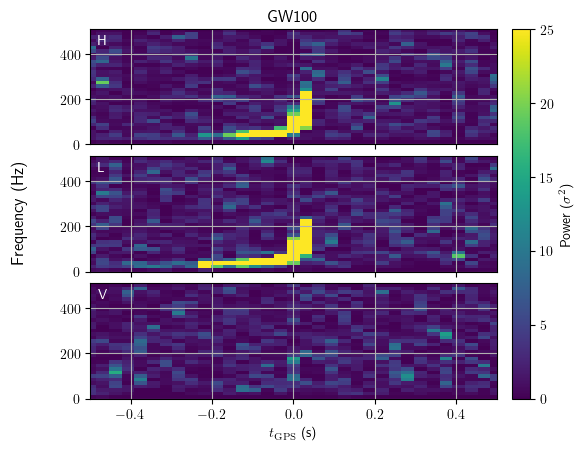

In [8]:
# check out the spectrogram
event_data.specgram(nfft=512)
kwargs = dict(
    fmax = 256,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))
plt.show()

In [9]:
# load the posterior samples
samples = load_posterior_samples(eventname, event_dir_list[i])
# add derived quantities
add_derived_quantities(samples)

loaded posterior samples for GW100 run 0


In [10]:
np.median(samples['lnl'])

np.float64(1958.4617088018767)

In [11]:
# SNR
np.sqrt(2 * np.median(samples['lnl']))

np.float64(62.58532909239795)

In [12]:
# plot the injected params
injected_par_dict = event_data.get_init_dict()['injection']['par_dic']
# also add the chirp mass
injected_par_dict['mchirp'] = chirp_mass(injected_par_dict['m1'], injected_par_dict['m2'])
injected_par_dict['chieff'] = cogwheel.gw_utils.chieff(injected_par_dict['m1'], injected_par_dict['m2'],
                                                        injected_par_dict['s1z'], injected_par_dict['s2z'])
# and a p_lensed — this event is unlensed
# injected_par_dict['p_lensed'] = 0.

In [13]:
# match the injected pars to plot
injected_pars_keys = ['m1', 'm2', 'iota']
# get the subset of the data release posterior parameters
injected_pars_to_plot = {}
for key, value in injected_par_dict.items():
    if key in injected_pars_keys:
        injected_pars_to_plot[key] = value

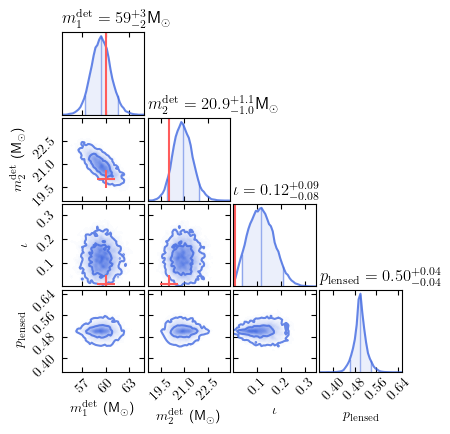

In [14]:
corner_plot = cogwheel.gw_plotting.CornerPlot(
        samples, params=plot_params, tail_probability=1e-4, color_2d='royalblue',
        kwargs_1d=dict(color='royalblue', alpha=0.8), contour_kwargs=dict(alpha=0.8)
)
corner_plot.plot(max_figsize=5)
corner_plot.scatter_points(injected_pars_to_plot, colors=['#FF5C5C'], s=150,
                               zorder=2, marker='+', adjust_lims=True)

In [15]:
# compute Bayes factor and uncertainty
n_resamples = 1000
bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
# log these
lnbayes_factors = np.log(bayes_factors)
# get the median and standard deviation
lnbayes, lnbayes_std = np.median(lnbayes_factors), np.std(lnbayes_factors)
print(lnbayes, lnbayes_std)

0.0016887069296778164 0.000932259837340386


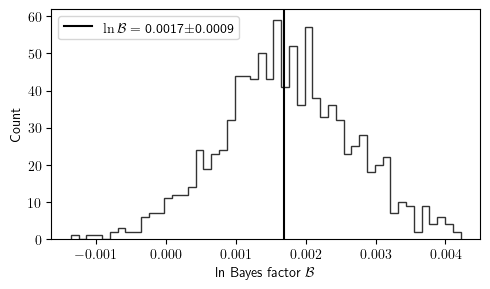

In [17]:
fig, ax = plt.subplots(figsize=(5,3), tight_layout=True)
_, _, _ = ax.hist(lnbayes_factors, histtype='step', color='k', alpha=0.8, bins=50)
ax.axvline(lnbayes, c='k', label=r'$\ln\mathcal{B} = $ 'f'{lnbayes:.4f}'r'$\pm$'f'{lnbayes_std:.4f}')
ax.set_xlabel(r'ln Bayes factor $\mathcal{B}$')
ax.set_ylabel('Count')
ax.legend()